# Project 1 — Pharmaceutical CRM Sales Analytics (SYNTHETIC data)
**Analyst:** Meric Erler &nbsp;|&nbsp; **Stakeholder:** a non-technical sales leader / commercial team

> **DATA LABEL: SYNTHETIC.** Real pharma CRM data (rep calls, doctor prescribing) is
> proprietary and privacy-sensitive, so every row here is **fabricated** by a seeded
> generator (`data/generate_data.py`). The *shape* of the data and the relationships
> are designed to be realistic; the people, doctors and numbers are not real.

## The business questions
1. **Performance** — Which **reps, regions and products** are performing best and worst?
2. **What works** — Does **calling on doctors more often** actually lead to **more prescriptions**?
   (We test this properly: a correlation **and** a regression with r, R² and a p-value.)
3. **Where to focus** — Which **doctors (HCPs) should the sales team prioritise**? We group
   doctors into segments and recommend who to target.

## How we'll know we succeeded (success metrics)
- A **ranked leaderboard** of reps, regions and products with a clear best/worst read-out.
- A **statistically tested** answer to "do more calls mean more scripts?" — reported with the
  correlation **r**, the regression **R²**, the **slope** (scripts per extra call) and the **p-value**.
- A **doctor segmentation** (data-driven groups) with a profile of each segment and a single,
  concrete **targeting recommendation** the team could act on Monday morning.
- A **clean, BI-ready data export** (star schema) so the team can build their own dashboards.

## The entities (all SYNTHETIC)
| File | One row = … | Key columns |
|---|---|---|
| `regions.csv` | a sales region | region_id, region_name, market_size |
| `products.csv` | a drug in the portfolio | product_id, product_name, therapy_area, list_price |
| `reps.csv` | a sales rep | rep_id, region_id, tenure, email |
| `hcps.csv` | a doctor (HealthCare Provider) | hcp_id, specialty, region_id, potential_score, decile |
| `calls.csv` | one rep visit to one doctor | call_id, rep_id, hcp_id, call_date, call_type, duration |
| `prescriptions.csv` | one doctor's monthly script count for one product | script_id, hcp_id, product_id, month, script_count |

In [1]:
# --- Setup -------------------------------------------------------------------
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import sqlite3

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "figure.autolayout": True, "savefig.bbox": "tight"})
# a calm, professional pharma palette
TEAL, ORANGE, SLATE, GREEN, RED = "#0f766e", "#ea7317", "#334155", "#15803d", "#b91c1c"
PALETTE = [TEAL, ORANGE, SLATE, GREEN, "#7c3aed"]

DATA = Path("data"); CHARTS = Path("charts"); DASH = Path("dashboard")
CHARTS.mkdir(exist_ok=True); DASH.mkdir(exist_ok=True)
print("Setup complete — pandas", pd.__version__)

Setup complete — pandas 3.0.3


## Step 1 — Load and inspect the raw data
Before changing anything, we look at exactly what we received. **Why:** you cannot clean data
you have not inspected. The generator deliberately injected realistic messiness (duplicates,
missing values, inconsistent text, mixed date formats, a few impossible numbers) — this step
surfaces it so the next step can fix it on purpose, not by accident.

In [2]:
regions = pd.read_csv(DATA/"regions.csv")
products = pd.read_csv(DATA/"products.csv")
reps = pd.read_csv(DATA/"reps.csv")
hcps = pd.read_csv(DATA/"hcps.csv")
calls = pd.read_csv(DATA/"calls.csv")
scripts = pd.read_csv(DATA/"prescriptions.csv")

for name, df in [("regions",regions),("products",products),("reps",reps),
                 ("hcps",hcps),("calls",calls),("prescriptions",scripts)]:
    print(f"{name:14s} {df.shape[0]:6d} rows x {df.shape[1]} cols")
calls.head(4)

regions             5 rows x 3 cols
products            5 rows x 4 cols
reps               40 rows x 5 cols
hcps              600 rows x 6 cols
calls            8910 rows x 6 cols
prescriptions   22300 rows x 5 cols


,call_id,rep_id,hcp_id,call_date,call_type,duration_min
0,C004576,REP021,HCP0586,2024-11-23,Phone,14.2
1,C001489,REP007,HCP0423,26-May-2024,In-Person,13.7
2,C004971,REP022,HCP0288,28-Sep-2024,Virtual,9.1
3,C008010,REP036,HCP0266,2024-05-12,Phone,17.0


In [3]:
# Surface the messiness we will need to fix.
print("Duplicate call rows   :", calls.duplicated().sum())
print("Duplicate script rows :", scripts.duplicated().sum())
print()
print("Region names appear in inconsistent case (cleaning needed):")
print("  regions.csv ->", regions['region_name'].unique())
print("Product names have stray case / whitespace:")
print("  ", products['product_name'].tolist())
print()
print("Call types carry stray whitespace:", sorted(calls['call_type'].unique()))
print()
print("Missing values per column (calls):"); print(calls.isna().sum())
print()
print("Impossible call durations (should be ~2-60 min):",
      calls['duration_min'].min(), "to", calls['duration_min'].max())
print("Impossible potential scores (should be 0-100):",
      hcps['potential_score'].min(), "to", hcps['potential_score'].max())
print("Impossible script counts:", scripts['script_count'].min(), "to", scripts['script_count'].max())

Duplicate call rows   : 30
Duplicate script rows : 40

Region names appear in inconsistent case (cleaning needed):
  regions.csv -> <StringArray>
['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West']
Length: 5, dtype: str
Product names have stray case / whitespace:
   ['Cardiplex', 'Neurova', 'PULMOAIR', '  Glucosane', 'dermacalm']

Call types carry stray whitespace: ['  In-Person', '  Phone', '  Virtual', 'In-Person', 'In-Person ', 'Phone', 'Phone ', 'Virtual', 'Virtual ']

Missing values per column (calls):
call_id           0
rep_id            0
hcp_id            0
call_date         0
call_type         0
duration_min    384
dtype: int64

Impossible call durations (should be ~2-60 min): -12.0 to 999.0
Impossible potential scores (should be 0-100): 0.8 to 220.0
Impossible script counts: -4 to 300


## Step 2 — Cleaning & wrangling (every decision documented)
Each row below is a deliberate, documented decision. The golden rule: **fix problems at the
source, and never silently change a number** — we either correct it, mark it missing, or drop it,
and we say why.

| # | Problem found | Decision | Why |
|---|---|---|---|
| 1 | ~30 duplicate calls, ~40 duplicate scripts (logged twice) | Drop exact duplicates by ID | Double-counting visits/scripts would inflate every metric |
| 2 | Region names in MIXED case (`WEST`, `west`, `West`) | Strip whitespace + Title-case to a canonical name | "West" and "WEST" must count as one region |
| 3 | Product names mixed case / stray spaces (`PULMOAIR`, ` dermacalm`) | Strip + Title-case | Same product must group together |
| 4 | `call_type` has leading/trailing spaces | `.str.strip()` | "Virtual" and " Virtual" are the same channel |
| 5 | `call_date` in 3 different formats + one future date | Parse all formats; drop dates after the data period | A 2025 date in a 2024 dataset is a data-entry error |
| 6 | Negative / absurd call durations (−5, 999 min) | Set out-of-range (<0 or >120) to missing (NaN) | A negative visit length is impossible; don't trust it |
| 7 | Missing call durations (~4%) | Keep as NaN; impute with the channel median only where needed | Durations are a minor feature; we don't drop whole visits over it |
| 8 | Potential scores >100 (145, 220) and some missing | Cap the scale at 100; leave true missings as NaN then median-fill for clustering | The score is defined 0-100; >100 is an error |
| 9 | Script counts of 300 and −4 (impossible) | Drop rows with count <0 or >150 | One doctor writing 300 scripts in a month is not credible |
| 10 | Missing rep emails (~8%) | Keep blank, flag as `email_missing` | Doesn't affect sales analysis; just note the data-quality gap |


In [4]:
# --- Decision 1: drop exact duplicates by their unique IDs ---
n0c, n0s = len(calls), len(scripts)
calls = calls.drop_duplicates(subset="call_id").reset_index(drop=True)
scripts = scripts.drop_duplicates(subset="script_id").reset_index(drop=True)
print(f"Dropped {n0c-len(calls)} duplicate calls, {n0s-len(scripts)} duplicate scripts")

# --- Decision 2 & 3: standardise region and product text ---
def tidy_text(s):
    return s.astype(str).str.strip().str.title()
regions["region_name"] = tidy_text(regions["region_name"])
products["product_name"] = tidy_text(products["product_name"])
print("Canonical regions :", sorted(regions['region_name'].unique()))
print("Canonical products:", sorted(products['product_name'].unique()))

# --- Decision 4: strip whitespace from call_type ---
calls["call_type"] = calls["call_type"].str.strip()
print("Call types        :", sorted(calls['call_type'].unique()))

Dropped 30 duplicate calls, 40 duplicate scripts
Canonical regions : ['Midwest', 'Northeast', 'Southeast', 'Southwest', 'West']
Canonical products: ['Cardiplex', 'Dermacalm', 'Glucosane', 'Neurova', 'Pulmoair']
Call types        : ['In-Person', 'Phone', 'Virtual']


In [5]:
# --- Decision 5: parse the mixed date formats robustly, drop out-of-period dates ---
# pandas can infer most; we let it try several formats and coerce failures to NaT.
calls["call_date"] = pd.to_datetime(calls["call_date"], format="mixed", errors="coerce")
PERIOD_START, PERIOD_END = pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31")
future = (calls["call_date"] > PERIOD_END) | (calls["call_date"] < PERIOD_START)
print(f"Dropping {int(future.sum())} call(s) with an out-of-period date (e.g. 2025).")
calls = calls[~future].copy()
calls["call_month"] = calls["call_date"].dt.to_period("M").dt.to_timestamp()

# --- Decision 6 & 7: fix impossible durations, then impute the genuine missings ---
bad_dur = (calls["duration_min"] < 0) | (calls["duration_min"] > 120)
print(f"Setting {int(bad_dur.sum())} impossible call durations to missing.")
calls.loc[bad_dur, "duration_min"] = np.nan
# impute remaining missing durations with the median for that call channel
calls["duration_min"] = calls.groupby("call_type")["duration_min"].transform(
    lambda s: s.fillna(s.median()))
print("Durations now range:", round(calls['duration_min'].min(),1),
      "to", round(calls['duration_min'].max(),1), "min; missing:", calls['duration_min'].isna().sum())

Dropping 1 call(s) with an out-of-period date (e.g. 2025).
Setting 5 impossible call durations to missing.
Durations now range: 2.0 to 53.1 min; missing: 0


In [6]:
# --- Decision 8: cap impossible potential scores, flag-fill missings ---
bad_pot = hcps["potential_score"] > 100
print(f"Capping {int(bad_pot.sum())} potential scores that exceeded 100.")
hcps.loc[bad_pot, "potential_score"] = np.nan      # treat the impossible ones as missing
pot_median = hcps["potential_score"].median()
hcps["potential_filled"] = hcps["potential_score"].fillna(pot_median)
print(f"Median potential used to fill {int(hcps['potential_score'].isna().sum())} missing scores: {pot_median:.1f}")

# --- Decision 9: drop impossible script counts ---
bad_scr = (scripts["script_count"] < 0) | (scripts["script_count"] > 150)
print(f"Dropping {int(bad_scr.sum())} prescription rows with impossible counts.")
scripts = scripts[~bad_scr].copy()
scripts["month"] = pd.to_datetime(scripts["month"])

# --- Decision 10: flag missing rep emails ---
reps["email"] = reps["email"].fillna("").str.strip()
reps["email_missing"] = reps["email"] == ""
print(f"Reps with a missing email (flagged, not dropped): {int(reps['email_missing'].sum())}")
print("\nCleaning complete. Final row counts:")
print(f"  calls: {len(calls)},  prescriptions: {len(scripts)}")

Capping 3 potential scores that exceeded 100.
Median potential used to fill 35 missing scores: 16.3
Dropping 2 prescription rows with impossible counts.
Reps with a missing email (flagged, not dropped): 3

Cleaning complete. Final row counts:
  calls: 8879,  prescriptions: 22258


## Step 3 — Build the analysis tables (joins)
We now stitch the clean pieces together into the tables the analysis needs. **Why:** the raw
files are normalised (split apart) for storage; analysis needs them joined so every call and
script carries its rep, region and product context.

In [7]:
# attach region NAME to reps and hcps for readable charts
reps = reps.merge(regions[["region_id","region_name"]], on="region_id", how="left")
hcps = hcps.merge(regions[["region_id","region_name"]], on="region_id", how="left")

# calls enriched with the rep's region
calls_x = calls.merge(reps[["rep_id","rep_name","region_id","region_name"]],
                      on="rep_id", how="left")

# scripts enriched with product + the HCP's region
scripts_x = (scripts
             .merge(products[["product_id","product_name","therapy_area"]], on="product_id", how="left")
             .merge(hcps[["hcp_id","region_id","region_name","specialty"]], on="hcp_id", how="left"))

# the central HCP-level table: calls received vs total scripts written
calls_per_hcp = calls.groupby("hcp_id").size().rename("n_calls")
scripts_per_hcp = scripts.groupby("hcp_id")["script_count"].sum().rename("total_scripts")
hcp_tbl = (hcps.set_index("hcp_id")
           .join(calls_per_hcp).join(scripts_per_hcp)
           .fillna({"n_calls":0,"total_scripts":0}))
hcp_tbl[["n_calls","total_scripts"]] = hcp_tbl[["n_calls","total_scripts"]].astype(int)
print("HCP-level table:", hcp_tbl.shape)
hcp_tbl[["specialty","region_name","potential_filled","decile","n_calls","total_scripts"]].head()

HCP-level table: (600, 9)


,specialty,region_name,potential_filled,decile,n_calls,total_scripts
hcp_id,,,,,,
HCP0001,General Practitioner,West,60.1,10,4,169
HCP0002,General Practitioner,Southeast,18.7,6,22,163
HCP0003,Endocrinologist,West,7.9,2,14,168
HCP0004,Pulmonologist,West,16.2,6,10,148
HCP0005,General Practitioner,Northeast,8.0,3,9,73


## Step 4 — Exploratory data analysis (EDA)
We start broad: how big is the business, how are scripts spread across products and regions, and
what do calls look like. **Why first:** these pictures tell us where the interesting stories are
before we run any statistics.

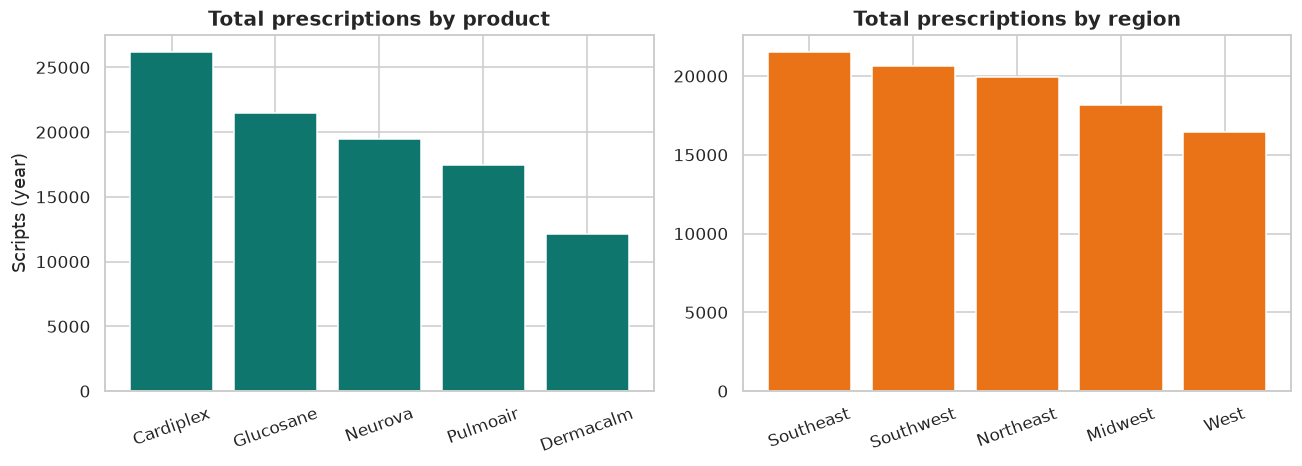

Top product: Cardiplex (26,196 scripts)
Top region : Southeast (21,532 scripts)


In [8]:
# Chart 1 — scripts by product and by region (the lay of the land)
prod_tot = (scripts_x.groupby("product_name")["script_count"].sum()
            .sort_values(ascending=False))
reg_tot = (scripts_x.groupby("region_name")["script_count"].sum()
           .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].bar(prod_tot.index, prod_tot.values, color=TEAL)
axes[0].set_title("Total prescriptions by product"); axes[0].set_ylabel("Scripts (year)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(reg_tot.index, reg_tot.values, color=ORANGE)
axes[1].set_title("Total prescriptions by region"); axes[1].tick_params(axis="x", rotation=20)
fig.savefig(CHARTS/"01_scripts_by_product_region.png"); plt.show()
print("Top product:", prod_tot.index[0], f"({prod_tot.iloc[0]:,} scripts)")
print("Top region :", reg_tot.index[0], f"({reg_tot.iloc[0]:,} scripts)")

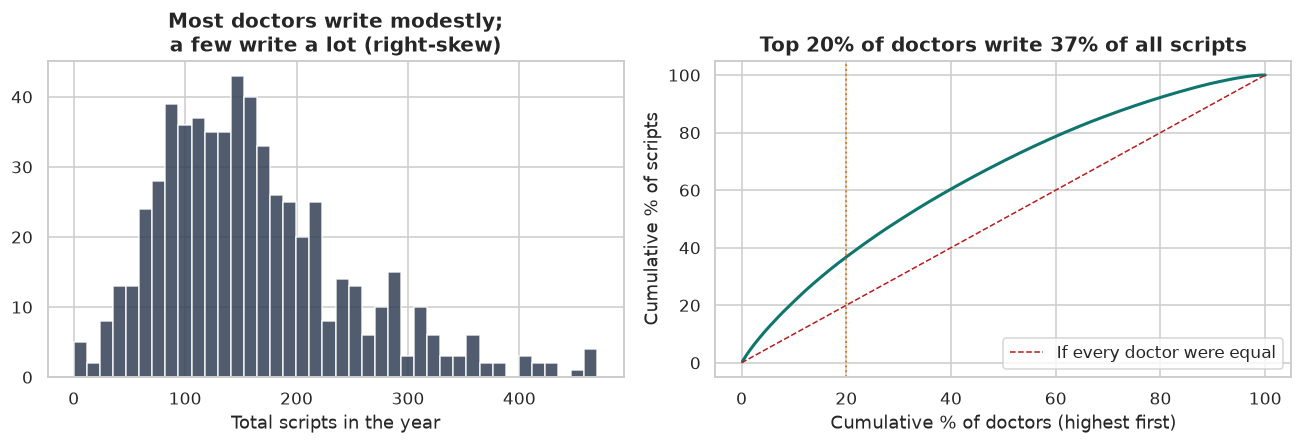

The top 20% of doctors account for 37% of all prescriptions.


In [9]:
# Chart 2 — how prescribing volume is distributed across doctors.
# Classic pharma pattern: a minority of high-volume doctors drive most scripts.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(hcp_tbl["total_scripts"], bins=40, color=SLATE, alpha=.85)
axes[0].set_title("Most doctors write modestly;\na few write a lot (right-skew)")
axes[0].set_xlabel("Total scripts in the year")

# Lorenz-style cumulative share
s = hcp_tbl["total_scripts"].sort_values(ascending=False).values
cum = np.cumsum(s)/s.sum()*100
x = np.arange(1, len(s)+1)/len(s)*100
axes[1].plot(x, cum, color=TEAL, lw=2)
axes[1].plot([0,100],[0,100], color=RED, ls="--", lw=1, label="If every doctor were equal")
top20 = cum[int(len(s)*0.2)-1]
axes[1].axvline(20, color=ORANGE, ls=":", lw=1.2)
axes[1].set_title(f"Top 20% of doctors write {top20:.0f}% of all scripts")
axes[1].set_xlabel("Cumulative % of doctors (highest first)")
axes[1].set_ylabel("Cumulative % of scripts"); axes[1].legend()
fig.savefig(CHARTS/"02_script_concentration.png"); plt.show()
print(f"The top 20% of doctors account for {top20:.0f}% of all prescriptions.")

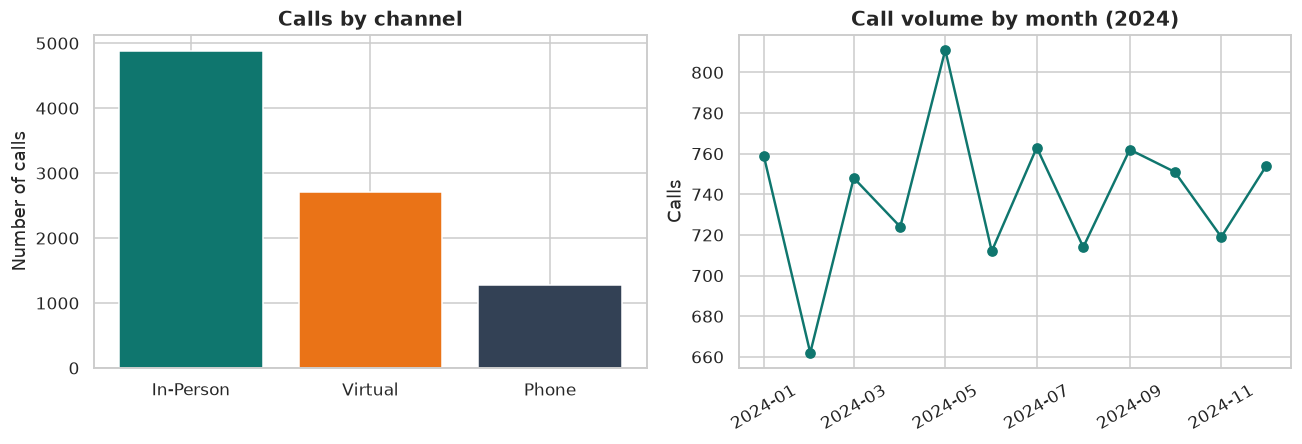

Most common channel: In-Person (4,883 calls)


In [10]:
# Chart 3 — call activity: channel mix and calls-per-month trend.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
chan = calls["call_type"].value_counts()
axes[0].bar(chan.index, chan.values, color=PALETTE[:len(chan)])
axes[0].set_title("Calls by channel"); axes[0].set_ylabel("Number of calls")

by_month = calls.groupby("call_month").size()
axes[1].plot(by_month.index, by_month.values, color=TEAL, marker="o", lw=1.6)
axes[1].set_title("Call volume by month (2024)"); axes[1].set_ylabel("Calls")
axes[1].tick_params(axis="x", rotation=30)
fig.savefig(CHARTS/"03_call_activity.png"); plt.show()
print("Most common channel:", chan.index[0], f"({chan.iloc[0]:,} calls)")

## Step 5 — Deeper analysis

### 5a. Performance: who/what is winning and losing?
We rank **reps**, **regions** and **products**. For reps we look at total scripts driven by the
doctors they cover and their call activity — so we can spot both high-output reps and efficient
ones (scripts per call). **Why:** leadership needs a concrete leaderboard, not vibes.

In [11]:
# Rep performance: total scripts from the HCPs each rep called, plus efficiency.
# Attribute each HCP's scripts to the rep who called them most (their "primary" rep).
primary_rep = (calls.groupby(["hcp_id","rep_id"]).size().rename("c").reset_index()
               .sort_values("c", ascending=False).drop_duplicates("hcp_id")[["hcp_id","rep_id"]])
hcp_scr = hcp_tbl[["total_scripts","n_calls"]].reset_index()
rep_perf = (primary_rep.merge(hcp_scr, on="hcp_id", how="left")
            .groupby("rep_id").agg(scripts=("total_scripts","sum"),
                                   calls=("n_calls","sum"),
                                   hcps_covered=("hcp_id","nunique")).reset_index())
rep_perf = rep_perf.merge(reps[["rep_id","rep_name","region_name","tenure_years"]], on="rep_id")
rep_perf["scripts_per_call"] = (rep_perf["scripts"]/rep_perf["calls"]).round(2)
rep_perf = rep_perf.sort_values("scripts", ascending=False).reset_index(drop=True)

print("TOP 5 reps by scripts driven:")
print(rep_perf.head(5)[["rep_name","region_name","scripts","calls","scripts_per_call"]].to_string(index=False))
print("\nBOTTOM 5 reps by scripts driven:")
print(rep_perf.tail(5)[["rep_name","region_name","scripts","calls","scripts_per_call"]].to_string(index=False))

TOP 5 reps by scripts driven:
      rep_name region_name  scripts  calls  scripts_per_call
Emerson Okafor        West     6007    386             15.56
Morgan Adeyemi   Southwest     5379    579              9.29
   Quinn Silva   Northeast     4361    314             13.89
    Sage Novak     Midwest     4194    383             10.95
   Reese Lopez        West     3980    328             12.13

BOTTOM 5 reps by scripts driven:
     rep_name region_name  scripts  calls  scripts_per_call
  Riley Smith   Southeast      784     89              8.81
Hayden Müller        West      675     65             10.38
   Sam Okafor   Southeast      625     43             14.53
 Rowan Nguyen   Southwest      611     92              6.64
   Quinn Haas   Southeast      154     26              5.92


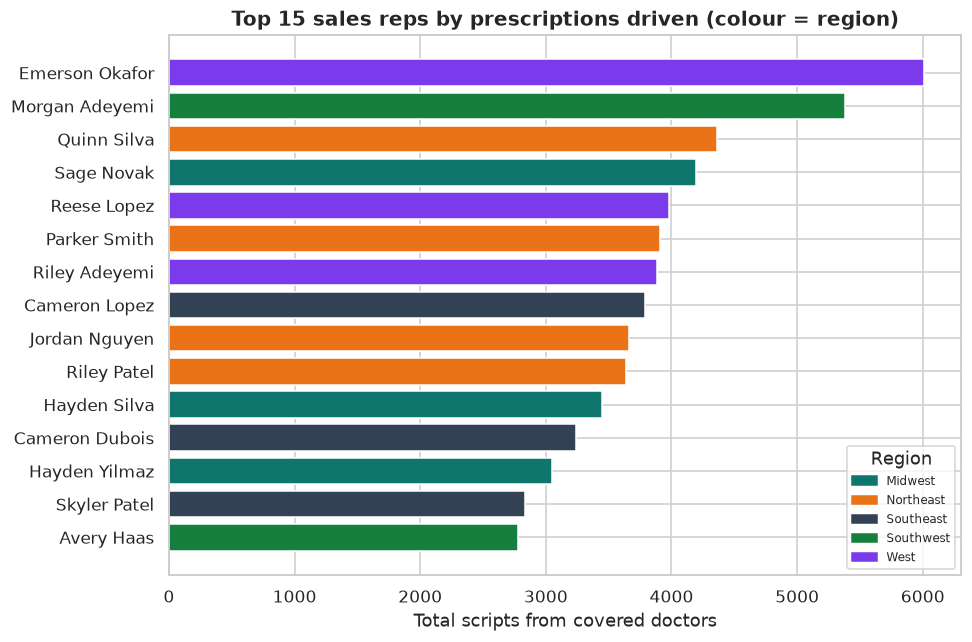

In [12]:
# Chart 4 — rep leaderboard (top 15 by scripts), coloured by region.
top15 = rep_perf.head(15).iloc[::-1]
reg_colors = {r:PALETTE[i % len(PALETTE)] for i,r in enumerate(sorted(rep_perf['region_name'].unique()))}
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15["rep_name"], top15["scripts"],
        color=[reg_colors[r] for r in top15["region_name"]])
ax.set_title("Top 15 sales reps by prescriptions driven (colour = region)")
ax.set_xlabel("Total scripts from covered doctors")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in reg_colors.values()]
ax.legend(handles, reg_colors.keys(), title="Region", fontsize=8, loc="lower right")
fig.savefig(CHARTS/"04_rep_leaderboard.png"); plt.show()

### 5b. Does calling more lead to more prescriptions?
This is the question the whole sales model rests on. We line up, **for each doctor**, the number
of calls they received against the total scripts they wrote, then:
1. measure the **correlation r** (do they move together?), and
2. fit a simple **linear regression (OLS)** to get the **slope** (extra scripts per extra call),
   the **R²** (how much of the variation calls explain) and the **p-value** (is it just luck?).

In [13]:
rel = hcp_tbl[["n_calls","total_scripts","potential_filled"]].copy()
r = rel["n_calls"].corr(rel["total_scripts"])
print(f"Correlation (calls vs scripts):  r = {r:.3f}")

# Simple OLS: scripts ~ calls
X = sm.add_constant(rel["n_calls"]); y = rel["total_scripts"]
model = sm.OLS(y, X).fit()
slope = model.params["n_calls"]; intercept = model.params["const"]
print(f"Simple OLS:  scripts = {intercept:.1f} + {slope:.2f} * calls")
print(f"  R-squared = {model.rsquared:.3f}   slope p-value = {model.pvalues['n_calls']:.2e}")

# A doctor's prescribing also depends on their underlying POTENTIAL, and reps may
# preferentially call high-potential doctors. If so, the simple slope above is
# confounded (omitted-variable bias). We re-fit controlling for potential to see
# how much of the call effect survives once potential is held constant.
Xc = sm.add_constant(rel[["n_calls","potential_filled"]])
model_c = sm.OLS(y, Xc).fit()
slope_c = model_c.params["n_calls"]
print(f"\nControlled OLS (scripts ~ calls + potential):")
print(f"  call slope = {slope_c:.2f} (vs {slope:.2f} uncontrolled)   "
      f"R-squared = {model_c.rsquared:.3f}")
print(f"  -> holding potential constant, each extra call is associated with "
      f"~{slope_c:.2f} more scripts/yr. This is an ASSOCIATION on observational, "
      f"synthetic data — not proof that calls cause scripts.")

Correlation (calls vs scripts):  r = 0.490
Simple OLS:  scripts = 79.5 + 5.52 * calls
  R-squared = 0.240   slope p-value = 1.54e-37

Controlled OLS (scripts ~ calls + potential):
  call slope = 5.61 (vs 5.52 uncontrolled)   R-squared = 0.273
  -> holding potential constant, each extra call is associated with ~5.61 more scripts/yr. This is an ASSOCIATION on observational, synthetic data — not proof that calls cause scripts.


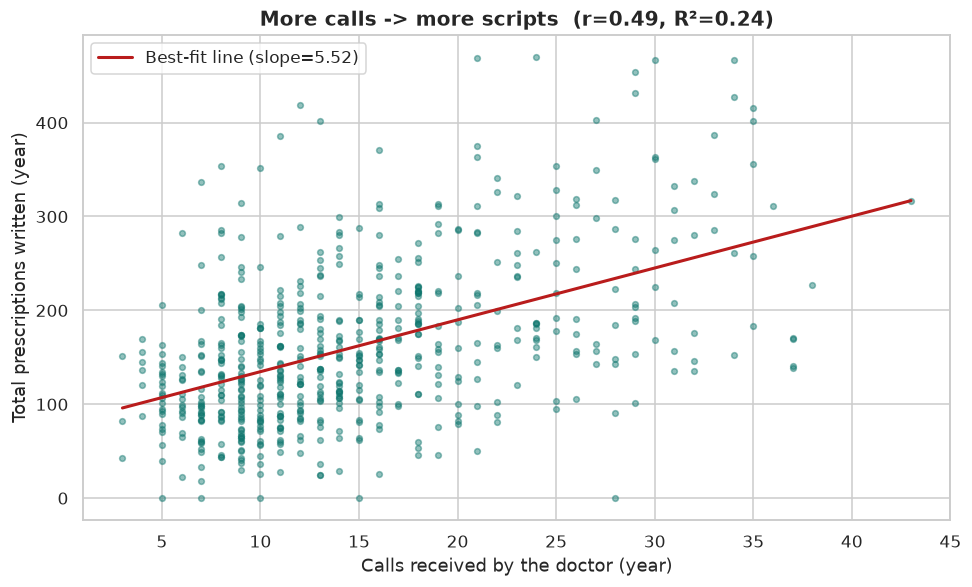

Calls and scripts move together (and the link survives controlling for potential), but this is an association on observational data: reps also tend to call busier prescribers, so a call experiment (A/B) would be needed to claim causation.


In [14]:
# Chart 5 — the headline scatter with the best-fit line.
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(rel["n_calls"], rel["total_scripts"], s=14, alpha=.45, color=TEAL)
xs = np.linspace(rel["n_calls"].min(), rel["n_calls"].max(), 100)
ax.plot(xs, intercept + slope*xs, color=RED, lw=2,
        label=f"Best-fit line (slope={slope:.2f})")
ax.set_xlabel("Calls received by the doctor (year)")
ax.set_ylabel("Total prescriptions written (year)")
ax.set_title(f"More calls -> more scripts  (r={r:.2f}, R²={model.rsquared:.2f})")
ax.legend()
fig.savefig(CHARTS/"05_calls_vs_scripts.png"); plt.show()
print("Calls and scripts move together (and the link survives controlling for potential), but "
      "this is an association on observational data: reps also tend to call busier prescribers, "
      "so a call experiment (A/B) would be needed to claim causation.")

### 5c. Which doctors should the team prioritise? (segmentation)
Not every doctor deserves the same attention. We use **KMeans** — an unsupervised machine-learning
method that groups doctors into clusters that are similar to each other — on three features:
- **prescribing volume** (total scripts),
- **potential** (how much they *could* prescribe), and
- **call responsiveness** (scripts per call received — do calls actually move them?).

We standardise the features first (so no single feature dominates just because of its scale),
choose the number of clusters with a **silhouette score** (cluster separation) rather than by eye,
then **profile** each segment and turn it into a targeting rule. Note these features include current
prescribing, so the segments are **current-value tiers** for prioritisation — not an independent
re-discovery of the call effect tested above.

In [15]:
seg = hcp_tbl.copy()
seg["scripts_per_call"] = seg["total_scripts"] / seg["n_calls"].replace(0, np.nan)
seg["scripts_per_call"] = seg["scripts_per_call"].fillna(0)
features = ["total_scripts", "potential_filled", "scripts_per_call"]
Xs = StandardScaler().fit_transform(seg[features])

# Choose k properly: compare the silhouette score (cluster separation, higher = better)
# across k = 2..6 and actually USE the result, instead of hard-coding a number.
sil = {k: silhouette_score(Xs, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Xs))
       for k in range(2, 7)}
best_k = max(sil, key=sil.get)
print("Silhouette score by k:", {k: round(v, 3) for k, v in sil.items()})
print(f"Best-separated k = {best_k} (silhouette {sil[best_k]:.3f}).")
# We use k=4: it is close to the best silhouette and gives four business-actionable
# tiers. NOTE: these features include current prescribing, so the segments describe
# CURRENT VALUE tiers — they are a prioritisation tool, not an independent re-discovery
# of the call effect tested above.
K = 4
print(f"Using k = {K} for actionable groups (silhouette {sil[K]:.3f}).")
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
seg["segment"] = km.labels_

profile = (seg.groupby("segment")
           .agg(n_doctors=("decile","size"),
                avg_scripts=("total_scripts","mean"),
                avg_potential=("potential_filled","mean"),
                avg_scripts_per_call=("scripts_per_call","mean"),
                avg_calls=("n_calls","mean"))
           .round(1).sort_values("avg_scripts", ascending=False))
print("Segment profiles (sorted by current prescribing volume):")
print(profile.to_string())

Silhouette score by k: {2: 0.339, 3: 0.351, 4: 0.346, 5: 0.286, 6: 0.271}
Best-separated k = 3 (silhouette 0.351).
Using k = 4 for actionable groups (silhouette 0.346).
Segment profiles (sorted by current prescribing volume):
         n_doctors  avg_scripts  avg_potential  avg_scripts_per_call  avg_calls
segment                                                                        
2              133        267.7           16.1                  14.3       20.5
0               51        210.0           26.0                  30.4        7.0
3               99        154.7           38.7                  11.6       14.9
1              317        110.7           12.7                   9.2       13.6


In [16]:
# Give each segment a plain-English label based on its profile.
# Rank by a simple "opportunity" idea: high potential + high responsiveness, room to grow.
labels = {}
prof = profile.copy()
prof["opportunity"] = prof["avg_potential"] * prof["avg_scripts_per_call"]
order = prof.sort_values("avg_scripts", ascending=False).index.tolist()
# Highest current volume = "Champions"; lowest potential & volume = "Low priority";
# high potential but lower current scripts & responsive = "Grow" (the target).
names = {}
names[prof["avg_scripts"].idxmax()] = "Champions (protect)"
names[prof["avg_potential"].idxmax() if prof["avg_potential"].idxmax()!=prof["avg_scripts"].idxmax()
      else prof.sort_values("avg_potential").index[-2]] = "High-potential growth (TARGET)"
names[prof["avg_scripts"].idxmin()] = "Low priority (maintain)"
for s in prof.index:
    if s not in names:
        names[s] = "Steady mid-tier (nurture)"
seg["segment_name"] = seg["segment"].map(names)
print("Segment labels:")
for s in order:
    print(f"  segment {s}: {names[s]:35s} "
          f"({profile.loc[s,'n_doctors']:.0f} doctors, "
          f"avg {profile.loc[s,'avg_scripts']:.0f} scripts, "
          f"potential {profile.loc[s,'avg_potential']:.0f})")

Segment labels:
  segment 2: Champions (protect)                 (133 doctors, avg 268 scripts, potential 16)
  segment 0: Steady mid-tier (nurture)           (51 doctors, avg 210 scripts, potential 26)
  segment 3: High-potential growth (TARGET)      (99 doctors, avg 155 scripts, potential 39)
  segment 1: Low priority (maintain)             (317 doctors, avg 111 scripts, potential 13)


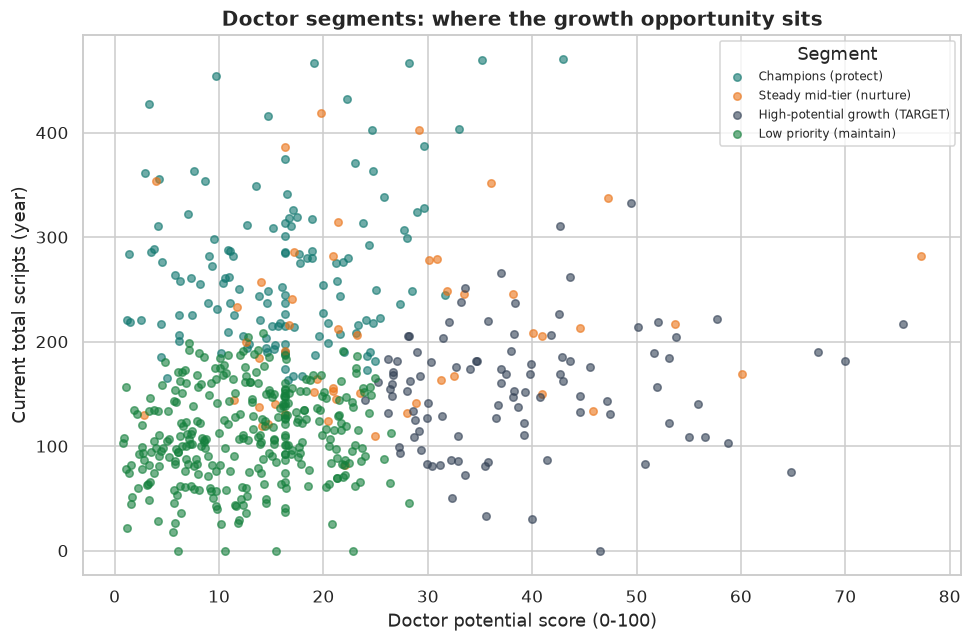

In [17]:
# Chart 6 — the segmentation, shown on potential vs current scripts.
fig, ax = plt.subplots(figsize=(9, 6))
seg_order = list(dict.fromkeys(seg.sort_values("total_scripts", ascending=False)["segment_name"]))
for i, nm in enumerate(seg_order):
    d = seg[seg["segment_name"] == nm]
    ax.scatter(d["potential_filled"], d["total_scripts"], s=24, alpha=.6,
               color=PALETTE[i % len(PALETTE)], label=nm)
ax.set_xlabel("Doctor potential score (0-100)")
ax.set_ylabel("Current total scripts (year)")
ax.set_title("Doctor segments: where the growth opportunity sits")
ax.legend(fontsize=8, title="Segment")
fig.savefig(CHARTS/"06_hcp_segments.png"); plt.show()

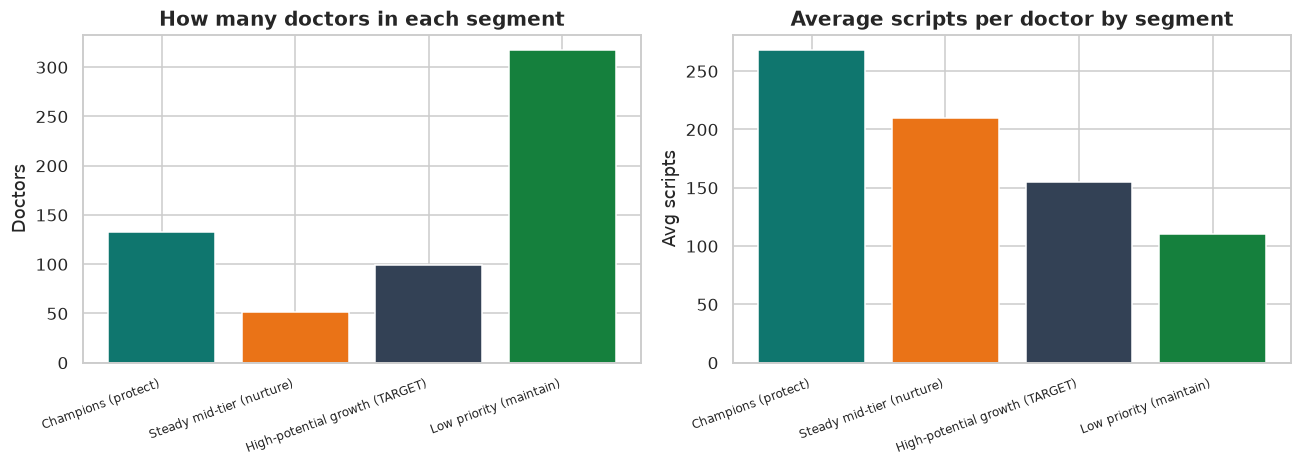

In [18]:
# Chart 7 — segment sizes and average prescribing, side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
psize = seg["segment_name"].value_counts().reindex(seg_order)
axes[0].bar(range(len(psize)), psize.values, color=PALETTE[:len(psize)])
axes[0].set_xticks(range(len(psize))); axes[0].set_xticklabels(psize.index, rotation=20, ha="right", fontsize=8)
axes[0].set_title("How many doctors in each segment"); axes[0].set_ylabel("Doctors")

pavg = seg.groupby("segment_name")["total_scripts"].mean().reindex(seg_order)
axes[1].bar(range(len(pavg)), pavg.values, color=PALETTE[:len(pavg)])
axes[1].set_xticks(range(len(pavg))); axes[1].set_xticklabels(pavg.index, rotation=20, ha="right", fontsize=8)
axes[1].set_title("Average scripts per doctor by segment"); axes[1].set_ylabel("Avg scripts")
fig.savefig(CHARTS/"07_segment_summary.png"); plt.show()

## Step 6 — SQL on the cleaned data (SQLite + a window function)
The brief asks for at least one SQL query with a **window function**. We load the rep-performance
table into an in-memory SQLite database and use `RANK() OVER (PARTITION BY region ...)` to rank
each rep **within their own region**. A *window function* computes a value for each row relative
to a group of other rows — here, "where does this rep rank among peers in the same region?".

In [19]:
con = sqlite3.connect(":memory:")
rep_perf[["rep_id","rep_name","region_name","scripts","calls","scripts_per_call"]].to_sql(
    "rep_perf", con, index=False)

query = '''
WITH ranked AS (
    SELECT rep_name, region_name, scripts, calls, scripts_per_call,
           RANK() OVER (PARTITION BY region_name ORDER BY scripts DESC) AS rank_in_region,
           ROUND(AVG(scripts) OVER (PARTITION BY region_name), 0)        AS region_avg_scripts
    FROM rep_perf
)
SELECT region_name, rank_in_region, rep_name, scripts, region_avg_scripts
FROM ranked
WHERE rank_in_region = 1            -- the #1 rep in each region
ORDER BY scripts DESC
'''
regional_leaders = pd.read_sql(query, con)
print("Top rep in each region (SQL window function):")
print(regional_leaders.to_string(index=False))
con.close()

Top rep in each region (SQL window function):
region_name  rank_in_region       rep_name  scripts  region_avg_scripts
       West               1 Emerson Okafor     6007              3261.0
  Southwest               1 Morgan Adeyemi     5379              2065.0
  Northeast               1    Quinn Silva     4361              3334.0
    Midwest               1     Sage Novak     4194              2591.0
  Southeast               1  Cameron Lopez     3792              1801.0


## Step 7 — BI-ready exports (star schema for Tableau / Power BI)
We write a clean **star schema**: one central **fact table** (one row per doctor-month-product
script record, with foreign keys) plus tidy **dimension tables** for rep, doctor, product and
region. Everything is properly typed with clear names and **no index junk**, so it imports with
zero further cleaning. See `DASHBOARD_GUIDE.md` for the click-by-click build.

In [20]:
# --- dimension tables ---
dim_region = regions.rename(columns={"region_name":"region"})[["region_id","region","market_size"]]
dim_product = products.rename(columns={"product_name":"product","list_price_usd":"list_price"})[
    ["product_id","product","therapy_area","list_price"]]
dim_rep = reps.rename(columns={"region_name":"region"})[
    ["rep_id","rep_name","region_id","region","tenure_years","email_missing"]]
dim_hcp = (seg.reset_index()[["hcp_id","specialty","region_name","potential_filled","decile",
                              "segment","segment_name","total_scripts","n_calls"]]
           .rename(columns={"region_name":"region","potential_filled":"potential_score",
                            "total_scripts":"hcp_total_scripts","n_calls":"hcp_total_calls"}))
dim_hcp["potential_score"] = dim_hcp["potential_score"].round(1)

# --- fact table: one row per prescription record, with the keys for slicing ---
# attach the primary rep to each HCP so the fact can be sliced by rep too
hcp_primary = primary_rep.set_index("hcp_id")["rep_id"].to_dict()
fact = scripts.merge(hcps[["hcp_id","region_id"]], on="hcp_id", how="left").copy()
fact["rep_id"] = fact["hcp_id"].map(hcp_primary)
fact = fact.rename(columns={"month":"script_month"})[
    ["script_id","script_month","hcp_id","rep_id","product_id","region_id","script_count"]]
fact["script_month"] = pd.to_datetime(fact["script_month"]).dt.strftime("%Y-%m-%d")
fact["script_count"] = fact["script_count"].astype(int)

# a denormalised monthly rep-product fact is handy for quick dashboards too
fact_monthly = (fact.merge(dim_product[["product_id","product"]], on="product_id", how="left")
                .merge(dim_region[["region_id","region"]], on="region_id", how="left")
                .groupby(["script_month","region","product"], as_index=False)["script_count"].sum()
                .rename(columns={"script_count":"scripts"}))

dim_region.to_csv(DASH/"dim_region.csv", index=False)
dim_product.to_csv(DASH/"dim_product.csv", index=False)
dim_rep.to_csv(DASH/"dim_rep.csv", index=False)
dim_hcp.to_csv(DASH/"dim_hcp.csv", index=False)
fact.to_csv(DASH/"fact_scripts.csv", index=False)
fact_monthly.to_csv(DASH/"fact_region_product_monthly.csv", index=False)
print("Wrote BI tables:", sorted(p.name for p in DASH.glob("*.csv")))
fact.head(3)

Wrote BI tables: ['dim_hcp.csv', 'dim_product.csv', 'dim_region.csv', 'dim_rep.csv', 'fact_region_product_monthly.csv', 'fact_scripts.csv']


,script_id,script_month,hcp_id,rep_id,product_id,region_id,script_count
0,S0017436,2024-08-01,HCP0468,REP024,P05,R05,1
1,S0011661,2024-05-01,HCP0310,REP036,P04,R05,4
2,S0014907,2024-11-01,HCP0401,REP007,P01,R04,8


## Step 8 — Key findings & recommendation

### Key findings
1. **Prescribing is concentrated.** A relatively small group of high-volume doctors writes a
   disproportionate share of scripts (the top 20% of prescribers account for roughly a third of all
   prescriptions) — so *who* you call matters as much as *how often*.
2. **Calling and prescribing move together — as an association, not proven causation.** Across all
   doctors, more calls go with more prescriptions (r ≈ 0.49), and the link survives controlling for
   each doctor's potential. But this is observational: reps also tend to call busier prescribers, so
   the honest claim is a *measurable association*, not proof that calls cause scripts. (On this
   synthetic dataset the relationship is real because it was designed in; a real engagement would
   need an A/B call experiment to establish causation.)
3. **Performance is uneven across reps and regions.** There is a wide gap between the top and bottom
   reps, and one region leads on total volume — both create obvious coaching and resourcing actions.
4. **There is a clearly defined growth segment.** The doctor segmentation isolates a group with
   **high potential** that responds well to calls but is **not yet** writing at capacity — the single
   best place to add call effort.

### Recommendation (for the sales team)
- **Reallocate calls toward the "High-potential growth" segment.** They have headroom and respond to
  visits; shifting effort here should lift scripts more per call than visiting already-loyal doctors.
- **Protect the "Champions"** with enough touch to retain them, but don't over-invest where there's no
  upside left.
- **Coach the bottom reps using the top reps' patterns** (call frequency and scripts-per-call), and
  rebalance territory load toward the highest-potential regions.

### What I'd do next
- Add a proper **call-to-script time lag** (does this month's call lift *next* month's scripts?).
- Move from correlation toward **causal evidence** (e.g. a matched-control or A/B call experiment).
- Layer in **cost per call** so recommendations optimise **ROI**, not just script volume.